# Hybrid spelling and punctuation assistant

This notebook is the main experiment surface for the current project architecture.

The project uses one final system:

```text
HybridCorrector = candidate generator + top-k edit Transformer + source-aware punctuation head + RuBERT context reranker + quality guard
```

The model does not rewrite the whole sentence. It predicts local token edits from top-k candidates and source-aware punctuation labels. V11 uses CPU-first RuBERT reranking, safer runtime gates, rank-consistent top-k labels, narrow split/phrase candidates, source-aware candidate scoring, mined train-pair confusions, full word-decision diagnostics, morphology-guarded dictionary gates, candidate-aware KEEP training and clean-noise filtering. V11 adds safety-first keyboard-neighbor, orthographic and mined train-pair candidates while keeping conservative runtime guards.


## 1. Environment

In [20]:
import os
import sys
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Jupyter keeps imported modules in memory. After code changes we must force
# the kernel to import the current files from src/, otherwise old model classes
# can be used and cell 20 may fail while loading/evaluating the model.
PROJECT_MODULES = [
    "candidate_generator",
    "data_preparation",
    "edit_labels",
    "external_datasets",
    "evaluate_hybrid",
    "evaluate_fred_t5",
    "hybrid_corrector",
    "hybrid_model",
    "hybrid_preprocessor",
    "morphology_guard",
    "quality_guard",
    "text_utils",
    "train_hybrid",
    "training_augmentation",
]
def reload_project_modules(names=None):
    names = PROJECT_MODULES if names is None else names
    for module_name in names:
        sys.modules.pop(module_name, None)

reload_project_modules()

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "0"
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")
warnings.filterwarnings("ignore", message=".*Some weights of.*BertForMaskedLM.*")
try:
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

import tensorflow as tf

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Project root:", ROOT)

for folder in ["models", "report", "report/figures", "data/processed"]:
    Path(folder).mkdir(parents=True, exist_ok=True)


Python: 3.10.12
TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Project root: /home/daniil/projects/ai-assistant


## 2. Experiment Configuration

Change hyperparameters here before running the rest of the notebook.


In [21]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Data paths
DATASET_PATH = Path("data/processed/dataset.csv")
TRAIN_PATH = Path("data/processed/train.csv")
VAL_PATH = Path("data/processed/val.csv")
TEST_PATH = Path("data/processed/test.csv")
RAW_TEXTS_PATH = Path("data/raw/texts.txt")
EXTERNAL_DATA_DIR = Path("data/external")
EXTERNAL_AI_FOREVER_PATH = EXTERNAL_DATA_DIR / "ai_forever_spellcheck_punctuation_test.csv"
EXTERNAL_RUSPELLGOLD_PATH = EXTERNAL_DATA_DIR / "ruspellgold_test.csv"

# Dataset regeneration from data/raw/texts.txt + V10 real-pairs
REGENERATE_DATASET = True
ENABLE_REAL_PAIRS = True
SAMPLES_PER_TEXT = 4
TRAIN_CLEAN_RATIO = 0.35
EVAL_CLEAN_RATIO = 0.35
REAL_TRAIN_REPEAT = 6
REAL_VAL_RATIO = 0.10
REAL_MAX_CHARS = 240
REAL_MAX_TOKENS = 96
EXTERNAL_REAL_MAX_CHARS = 280
EXTERNAL_REAL_MAX_TOKENS = 128

TRAIN_CURRICULUM = [
    {"name": "spelling_light", "profile": "spelling_light", "p": 0.18},
    {"name": "spelling_medium", "profile": "spelling_medium", "p": 0.16},
    {"name": "orthography_rules", "profile": "orthography_rules", "p": 0.16},
    {"name": "punctuation_only", "profile": "punctuation_only", "p": 0.18},
    {"name": "punctuation_structural", "profile": "punctuation_structural", "p": 0.18},
    {"name": "mixed", "profile": "mixed", "p": 0.10},
    {"name": "hard", "profile": "hard", "p": 0.04},
]

EVAL_CURRICULUM = [
    {"name": "spelling_light", "profile": "spelling_light", "p": 0.24},
    {"name": "spelling_medium", "profile": "spelling_medium", "p": 0.13},
    {"name": "orthography_rules", "profile": "orthography_rules", "p": 0.14},
    {"name": "punctuation_only", "profile": "punctuation_only", "p": 0.25},
    {"name": "punctuation_structural", "profile": "punctuation_structural", "p": 0.16},
    {"name": "mixed", "profile": "mixed", "p": 0.06},
    {"name": "hard", "profile": "hard", "p": 0.02},
]

# Hybrid labels and model
MODEL_VERSION = 11
MAX_LENGTH = 128
MIN_VOCAB_FREQ = 1
MAX_VOCAB_SIZE = 80_000
CANDIDATE_MIN_FREQ = 1
CANDIDATE_MAX_DISTANCE = 1
LONG_OOV_MAX_DISTANCE = 2
LONG_OOV_MIN_LENGTH = 8
CANDIDATE_TOP_K = 16
MIN_DICTIONARY_SCORE = 0.25
SAFE_SPLIT_CANDIDATES = True
ENABLE_KEYBOARD_CANDIDATES = True
ENABLE_ORTHOGRAPHIC_CANDIDATES = True
ENABLE_MINED_CONFUSIONS = True
MINED_CONFUSION_MIN_COUNT = 2

D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT_RATE = 0.30
LEARNING_RATE = 1e-4

# Candidate-aware KEEP augmentation
KEEP_CANDIDATE_AUGMENTATION = True
KEEP_CANDIDATE_PROBABILITY = 0.35
KEEP_CANDIDATE_MAX_PER_EXAMPLE = 3
KEEP_CANDIDATE_MAX_SEARCHES = 50_000
KEEP_CANDIDATE_CLEAN_ONLY = True
CLEAN_AUDIT_MAX_WORD_SEARCHES = 5_000

# Action and punctuation training weights
CLEAN_ACTION_KEEP_WEIGHT = 2.0
DIRTY_ACTION_KEEP_WEIGHT = 0.8
ACTION_CHANGE_WEIGHT = 4.0
PUNCT_CHANGE_WEIGHT = 8.0
FINAL_PUNCT_WEIGHT = 8.0
CLEAN_PUNCT_KEEP_WEIGHT = 4.0
DIRTY_PUNCT_KEEP_WEIGHT = 1.0

# Training
BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 2

# Context reranker
CONTEXT_RERANKER_ENABLED = True
CONTEXT_MODEL_NAME = "DeepPavlov/rubert-base-cased"
CONTEXT_DEVICE = "auto"  # uses CUDA for RuBERT when stable, falls back to CPU on scoring errors
CONTEXT_MARGIN = 0.25
USE_ENTITY_GUARD = True

# Evaluation
EVAL_SAMPLE_SIZE = None  # set None for full test split
EXTERNAL_EVAL_SAMPLE_SIZE = None
RUN_EXTERNAL_EVAL = False
WRITE_DIAGNOSTICS = True
INFERENCE_BATCH_SIZE = 512

# FRED-T5 baseline evaluation
RUN_FRED_T5_TEST_EVAL = True
RUN_FRED_T5_EXTERNAL_EVAL = True
FRED_T5_MODEL_NAME = "ai-forever/sage-fredt5-large"
# Base `ai-forever/FRED-T5-1.7B` is not instruction-tuned and tends to continue the prompt.
# For a meaningful spell/punctuation baseline use the correction-finetuned FRED/SAGE model below.
FRED_T5_PROMPT_TEMPLATE = "{text}"
# To reproduce the raw base-model ablation, set:
# FRED_T5_MODEL_NAME = "ai-forever/FRED-T5-1.7B"
# FRED_T5_PROMPT_TEMPLATE = "<LM>{text}"
FRED_T5_TEST_SAMPLE_SIZE = 200
FRED_T5_EXTERNAL_EVAL_SAMPLE_SIZE = 200
FRED_T5_TEST_OUTPUT_DIR = Path("report/fred_t5_test_v11_sample")
FRED_T5_EXTERNAL_AI_FOREVER_OUTPUT_DIR = Path("report/fred_t5_external_ai_forever_v11_sample")
FRED_T5_EXTERNAL_RUSPELLGOLD_OUTPUT_DIR = Path("report/fred_t5_external_ruspellgold_v11_sample")
FRED_T5_DEVICE = "auto"  # cuda if available, otherwise cpu
FRED_T5_DTYPE = "auto"   # float16 on cuda, float32 on cpu
FRED_T5_BATCH_SIZE = 1
FRED_T5_MAX_INPUT_TOKENS = None
FRED_T5_MAX_NEW_TOKENS = 192
FRED_T5_USE_DYNAMIC_MAX_LENGTH = True
FRED_T5_MAX_LENGTH_MULTIPLIER = 1.5
FRED_T5_NUM_BEAMS = 1
FRED_T5_REPETITION_PENALTY = 1.0
FRED_T5_NO_REPEAT_NGRAM_SIZE = 0
FRED_T5_LENGTH_PENALTY = 1.0
FRED_T5_DOWNLOAD_PROGRESS = True

EVAL_OUTPUT_DIR = Path("report/synthetic_v11")
STRICTNESS = "strict"  # strict | normal | aggressive
PUNCTUATION_MODE = "conservative"  # conservative | none | legacy

MODEL_PATH = Path("models/hybrid_corrector.keras")
PREPROCESSOR_PATH = Path("models/hybrid_preprocessor.pkl")
CANDIDATE_GENERATOR_PATH = Path("models/candidate_generator.pkl")
CONFIG_PATH = Path("models/hybrid_config.json")
TRAINING_LOG_PATH = Path("models/hybrid_training_log.csv")


## 3. Optional Dataset Regeneration

This cell uses the current project generator. V11 keeps generation conservative, while the candidate stage can use keyboard-neighbor and mined train-pair confusions.


In [35]:
from data_preparation import DatasetGenerator, split_texts
from external_datasets import (
    build_ai_forever_external_eval,
    build_ai_forever_train_val,
    build_ruspellgold_external_eval,
)

real_train_stats = {}
external_ai_forever_stats = {}
external_ruspellgold_stats = {}

if REGENERATE_DATASET:
    if not RAW_TEXTS_PATH.exists():
        raise FileNotFoundError(f"Missing raw texts: {RAW_TEXTS_PATH}")

    generator = DatasetGenerator()
    texts = generator.load_texts_from_file(str(RAW_TEXTS_PATH))
    train_texts, val_texts, test_texts = split_texts(
        texts,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1,
        seed=SEED,
    )

    df_train = generator.generate_dataset_curriculum(
        train_texts,
        samples_per_text=SAMPLES_PER_TEXT,
        clean_ratio=TRAIN_CLEAN_RATIO,
        curriculum=TRAIN_CURRICULUM,
    )
    df_train["split"] = "train"
    df_train = pd.concat([df_train, generator.curated_v10_examples("train")], ignore_index=True)

    df_val = generator.generate_dataset_curriculum(
        val_texts,
        samples_per_text=1,
        clean_ratio=EVAL_CLEAN_RATIO,
        curriculum=EVAL_CURRICULUM,
    )
    df_val["split"] = "val"
    df_val = pd.concat([df_val, generator.curated_v10_examples("val")], ignore_index=True)

    df_test = generator.generate_dataset_curriculum(
        test_texts,
        samples_per_text=1,
        clean_ratio=EVAL_CLEAN_RATIO,
        curriculum=EVAL_CURRICULUM,
    )
    df_test["split"] = "test"
    df_test = pd.concat([df_test, generator.curated_v10_examples("test")], ignore_index=True)

    if ENABLE_REAL_PAIRS:
        EXTERNAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
        real_train_df, real_val_df, real_train_stats = build_ai_forever_train_val(
            cache_dir=EXTERNAL_DATA_DIR,
            val_ratio=REAL_VAL_RATIO,
            repeat_train=REAL_TRAIN_REPEAT,
            seed=SEED,
            max_chars=REAL_MAX_CHARS,
            max_tokens=REAL_MAX_TOKENS,
        )
        print("AI Forever real train stats:", real_train_stats)
        df_train = pd.concat([df_train, real_train_df], ignore_index=True)
        df_val = pd.concat([df_val, real_val_df], ignore_index=True)

        external_ai_forever_df, external_ai_forever_stats = build_ai_forever_external_eval(
            cache_dir=EXTERNAL_DATA_DIR,
            max_chars=EXTERNAL_REAL_MAX_CHARS,
            max_tokens=EXTERNAL_REAL_MAX_TOKENS,
        )
        external_ruspellgold_df, external_ruspellgold_stats = build_ruspellgold_external_eval(
            cache_dir=EXTERNAL_DATA_DIR,
            max_chars=EXTERNAL_REAL_MAX_CHARS,
            max_tokens=EXTERNAL_REAL_MAX_TOKENS,
        )
        external_ai_forever_df.to_csv(EXTERNAL_AI_FOREVER_PATH, index=False, encoding="utf-8")
        external_ruspellgold_df.to_csv(EXTERNAL_RUSPELLGOLD_PATH, index=False, encoding="utf-8")
        print("External AI Forever rows:", len(external_ai_forever_df), external_ai_forever_stats, "->", EXTERNAL_AI_FOREVER_PATH)
        print("External RuSpellGold rows:", len(external_ruspellgold_df), external_ruspellgold_stats, "->", EXTERNAL_RUSPELLGOLD_PATH)

    df = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df.to_csv(DATASET_PATH, index=False, encoding="utf-8")
    df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    df_val.to_csv(VAL_PATH, index=False, encoding="utf-8")
    df_test.to_csv(TEST_PATH, index=False, encoding="utf-8")

    print("Regenerated dataset:", len(df))
    print("Train/val/test:", len(df_train), len(df_val), len(df_test))
    if "source_kind" in df.columns:
        display(df.groupby(["split", "source_kind"]).size().rename("rows").reset_index())
else:
    print("Dataset regeneration skipped.")


Генерация датасета (CURRICULUM)...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47997/47997 [00:17<00:00, 2702.68it/s]


Создано 191988 примеров (curriculum)
Генерация датасета (CURRICULUM)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5999/5999 [00:00<00:00, 12764.64it/s]


Создано 5999 примеров (curriculum)
Генерация датасета (CURRICULUM)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6001/6001 [00:00<00:00, 13242.19it/s]


Создано 6001 примеров (curriculum)
AI Forever real train stats: {'input': 5569, 'kept': 3560, 'identical': 894, 'spacing_only': 158, 'not_edit_compatible': 74, 'too_long': 848, 'heavy_rewrite': 32, 'large_token_count_shift': 3, 'train_rows_before_repeat': 3204, 'train_rows_after_repeat': 19224, 'val_rows': 356}
External AI Forever rows: 6119 {'input': 8036, 'kept': 6119, 'too_long': 1076, 'heavy_rewrite': 24, 'large_token_count_shift': 7, 'identical': 666, 'spacing_only': 144} -> data/external/ai_forever_spellcheck_punctuation_test.csv
External RuSpellGold rows: 713 {'input': 1711, 'kept': 713, 'identical': 767, 'too_long': 71, 'spacing_only': 160} -> data/external/ruspellgold_test.csv
Regenerated dataset: 223634
Train/val/test: 211234 6377 6023


,split,source_kind,rows
0,test,synthetic,6023
1,train,real,19224
2,train,synthetic,192010
3,val,real,356
4,val,synthetic,6021


## 4. Load And Inspect Dataset

Dataset rows: 223634
Train/val/test: 211234 6377 6023


,error_text,correct_text,difficulty,error_types,source_kind,source_dataset,source_domain,split
0,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",mixed,spelling_extra|spelling_double|punct_remove_fi...,synthetic,synthetic,NaN,train
1,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",orthography_rules,spelling_extra,synthetic,synthetic,NaN,train
2,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",clean,clean,synthetic,synthetic,NaN,train
3,"Именно ему и припсывают авторство идеи, но сам...","Именно ему и приписывают авторство идеи, но са...",spelling_medium,spelling_delete,synthetic,synthetic,NaN,train
4,По (официальной) информации Управления ветерин...,По официальной информации Управления ветеринар...,punctuation_structural,punct_bracket_extra,synthetic,synthetic,NaN,train


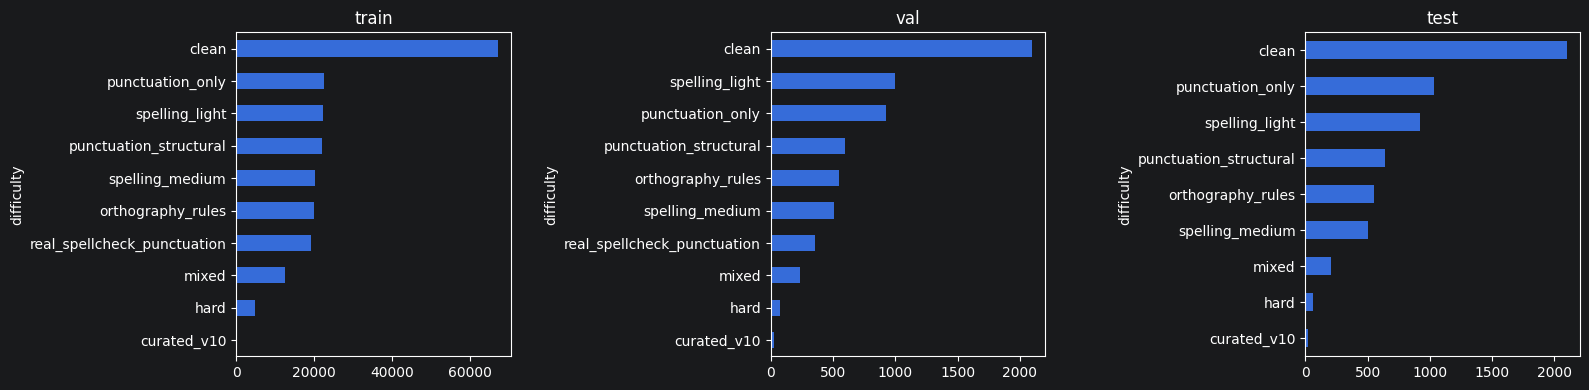

In [36]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH, low_memory=False)
if "split" in df.columns:
    df_train = df[df["split"] == "train"].copy()
    df_val = df[df["split"] == "val"].copy()
    df_test = df[df["split"] == "test"].copy()
else:
    df_train = pd.read_csv(TRAIN_PATH)
    df_val = pd.read_csv(VAL_PATH)
    df_test = pd.read_csv(TEST_PATH)

print("Dataset rows:", len(df))
print("Train/val/test:", len(df_train), len(df_val), len(df_test))
display(df.head(5))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, part, title in [
    (axes[0], df_train, "train"),
    (axes[1], df_val, "val"),
    (axes[2], df_test, "test"),
]:
    part["difficulty"].value_counts().sort_values().plot(kind="barh", ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 5. Build Hybrid Training Labels

In [37]:
reload_project_modules(["candidate_generator", "edit_labels", "training_augmentation", "text_utils", "morphology_guard"])
from candidate_generator import CandidateGenerator
from edit_labels import build_examples_from_dataframe
from training_augmentation import filter_noisy_clean_rows

provisional_generator = CandidateGenerator.from_texts(
    df_train["correct_text"].dropna().astype(str).tolist(),
    min_freq=CANDIDATE_MIN_FREQ,
    max_distance=CANDIDATE_MAX_DISTANCE,
    allow_split_candidates=False,
)

all_rows = pd.concat([df_train, df_val, df_test], ignore_index=True)
_, clean_noise_audit, suspicious_texts = filter_noisy_clean_rows(
    all_rows,
    provisional_generator,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    max_word_searches=CLEAN_AUDIT_MAX_WORD_SEARCHES,
)
clean_noise_filter_path = Path("report/clean_noise_filter.csv")
clean_noise_audit.to_csv(clean_noise_filter_path, index=False, encoding="utf-8")
print("Clean noise filter rows:", len(clean_noise_audit), "->", clean_noise_filter_path)

if suspicious_texts:
    df_train = df_train.loc[~df_train["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df_val = df_val.loc[~df_val["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df_test = df_test.loc[~df_test["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df.to_csv(DATASET_PATH, index=False, encoding="utf-8")
    df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    df_val.to_csv(VAL_PATH, index=False, encoding="utf-8")
    df_test.to_csv(TEST_PATH, index=False, encoding="utf-8")
    print("Filtered dataset rows:", len(df), "removed texts:", len(suspicious_texts))

train_examples, train_label_stats = build_examples_from_dataframe(df_train, max_tokens=MAX_LENGTH)
val_examples, val_label_stats = build_examples_from_dataframe(df_val, max_tokens=MAX_LENGTH)

print("Train label stats:", train_label_stats)
print("Val label stats:", val_label_stats)

if not train_examples or not val_examples:
    raise RuntimeError("Not enough aligned hybrid examples. Check dataset quality and MAX_LENGTH.")

if not hasattr(train_examples[0], "source_punct_labels"):
    raise RuntimeError("Stale edit_labels module detected. Rerun cell 2, then rerun cells 10-12.")

action_counter = Counter(label for ex in train_examples for label in ex.action_labels)
punct_counter = Counter(label or "NONE" for ex in train_examples for label in ex.target_punct_labels)
source_punct_counter = Counter(label or "NONE" for ex in train_examples for label in ex.source_punct_labels)

print("Action labels:", action_counter)
print("Source punctuation labels:", source_punct_counter)
print("Target punctuation labels:", punct_counter)
if len(clean_noise_audit):
    display(clean_noise_audit.head(10))


Clean noise filter rows: 799 -> report/clean_noise_filter.csv
Filtered dataset rows: 220858 removed texts: 799
Train label stats: {'rows': 208622, 'kept': 208621, 'skipped': 1, 'clean': 66392}
Val label stats: {'rows': 6305, 'kept': 6305, 'skipped': 0, 'clean': 2073}
Action labels: Counter({'KEEP': 2726302, 'REPLACE_0': 130883, 'DELETE': 853})
Source punctuation labels: Counter({'NONE': 2331095, ',': 216095, '.': 165639, '(': 33949, ')': 26886, '«': 22805, '"': 13591, '—': 10123, '».': 7900, ').': 5338, ':': 5210, '?': 4373, '»,': 4079, '".': 3241, '!': 1735, '...': 1662, '",': 1657, ':"': 813, ';': 509, ':«': 422, ',"': 384, ',»': 198, '!"': 82, '?»': 47, '."': 47, '!»': 43, '?"': 41, '....': 41, ':—': 17, '.»': 16})
Target punctuation labels: Counter({'NONE': 2356637, ',': 217156, '.': 184460, '«': 25180, '"': 12358, '—': 10419, '».': 9302, '(': 9075, ':': 5687, '?': 4728, ')': 4578, '»,': 4297, '".': 3918, ').': 3387, '",': 1566, '!': 1295, '...': 1190, ':"': 1132, ';': 506, ':«': 4

,word,candidate,candidate_score,candidate_distance,text
0,действующих,действующий,2.394449,1,Еще по предварительным итогам голосования стал...
1,посколько,поскольку,4.289716,1,"Дашкова: Я сейчас буду раздваиваться, поскольк..."
2,газоскреба,газоскреб,0.564949,1,Вишневский — «Высотная мания величия» Вы будет...
3,совершенным,совершенные,1.496508,1,"Так называемой «банде Боровикова», арестованно..."
4,месье,месте,5.013016,1,Изображенное тут же вмонтированное в стену кат...
5,открытым,открытый,2.043051,1,Пятитонный слон внезапно погнался за открытым ...
6,физлица,физлиц,0.833213,1,"Большинство сдают жилье как физлица, самозанят..."
7,личной,лично,3.433722,1,Одной из главных тем картины стала взаимосвязь...
8,следующей,следующий,3.814131,1,Референт начальника предприятия Геннадий Сорок...
9,основных,основные,2.744932,1,В 2001 году фильм был удостоен шести японских ...


## 6. Candidate Generator And Vectorization

In [38]:
reload_project_modules(["candidate_generator", "hybrid_preprocessor", "training_augmentation", "morphology_guard", "text_utils"])
from candidate_generator import CandidateGenerator
from hybrid_preprocessor import HybridPreprocessor
from training_augmentation import augment_keep_candidates, build_clean_candidate_audit, populate_top_k_candidates

candidate_generator = CandidateGenerator.from_texts(
    df_train["correct_text"].dropna().astype(str).tolist(),
    min_freq=CANDIDATE_MIN_FREQ,
    max_distance=CANDIDATE_MAX_DISTANCE,
    allow_split_candidates=SAFE_SPLIT_CANDIDATES,
    safe_split_only=True,
    long_oov_max_distance=LONG_OOV_MAX_DISTANCE,
    long_oov_min_length=LONG_OOV_MIN_LENGTH,
    enable_keyboard_candidates=ENABLE_KEYBOARD_CANDIDATES,
    enable_orthographic_candidates=ENABLE_ORTHOGRAPHIC_CANDIDATES,
    enable_mined_confusions=ENABLE_MINED_CONFUSIONS,
)
mined_confusion_stats = {"pairs": 0, "replace_segments": 0, "accepted": 0}
if ENABLE_MINED_CONFUSIONS:
    mining_rows = df_train.dropna(subset=["error_text", "correct_text"])
    mined_confusion_stats = candidate_generator.fit_mined_confusions(
        mining_rows["error_text"].astype(str).tolist(),
        mining_rows["correct_text"].astype(str).tolist(),
        min_count=MINED_CONFUSION_MIN_COUNT,
    )
print("Mined train confusions:", mined_confusion_stats)
candidate_generator.save(CANDIDATE_GENERATOR_PATH)
print("Candidate generator saved:", CANDIDATE_GENERATOR_PATH)
print("Known vocabulary size:", len(candidate_generator.frequencies))

clean_audit = build_clean_candidate_audit(
    pd.concat([df_train, df_val, df_test], ignore_index=True),
    candidate_generator,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    max_word_searches=CLEAN_AUDIT_MAX_WORD_SEARCHES,
)
clean_audit_path = Path("report/clean_candidate_audit.csv")
clean_audit.to_csv(clean_audit_path, index=False, encoding="utf-8")
print("Clean candidate audit rows:", len(clean_audit), "->", clean_audit_path)
if len(clean_audit):
    display(clean_audit.head(10))

train_examples, train_topk_candidate_stats = populate_top_k_candidates(
    train_examples,
    candidate_generator,
    candidate_top_k=CANDIDATE_TOP_K,
)
val_examples, val_topk_candidate_stats = populate_top_k_candidates(
    val_examples,
    candidate_generator,
    candidate_top_k=CANDIDATE_TOP_K,
)
print("Top-k train candidate stats:", train_topk_candidate_stats)
print("Top-k val candidate stats:", val_topk_candidate_stats)
print("Train target rank distribution:", train_topk_candidate_stats.get("target_rank_distribution", {}))
print("Train candidate coverage:", train_topk_candidate_stats.get("candidate_coverage_rate"))

train_examples, train_keep_candidate_stats = augment_keep_candidates(
    train_examples,
    candidate_generator,
    enabled=KEEP_CANDIDATE_AUGMENTATION,
    probability=KEEP_CANDIDATE_PROBABILITY,
    max_per_example=KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    max_candidate_searches=KEEP_CANDIDATE_MAX_SEARCHES,
    clean_only=KEEP_CANDIDATE_CLEAN_ONLY,
    seed=SEED,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
)
val_examples, val_keep_candidate_stats = augment_keep_candidates(
    val_examples,
    candidate_generator,
    enabled=KEEP_CANDIDATE_AUGMENTATION,
    probability=KEEP_CANDIDATE_PROBABILITY,
    max_per_example=KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    max_candidate_searches=max(1, KEEP_CANDIDATE_MAX_SEARCHES // 4),
    clean_only=KEEP_CANDIDATE_CLEAN_ONLY,
    seed=SEED + 1,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
)
print("Candidate-aware train KEEP stats:", train_keep_candidate_stats)
print("Candidate-aware val KEEP stats:", val_keep_candidate_stats)

preprocessor = HybridPreprocessor(
    max_length=MAX_LENGTH,
    min_freq=MIN_VOCAB_FREQ,
    max_vocab_size=MAX_VOCAB_SIZE,
    candidate_top_k=CANDIDATE_TOP_K,
)
preprocessor.fit(train_examples)
preprocessor.save(PREPROCESSOR_PATH)

x_train, y_train, sw_train = preprocessor.vectorize_examples(
    train_examples,
    clean_action_keep_weight=CLEAN_ACTION_KEEP_WEIGHT,
    dirty_action_keep_weight=DIRTY_ACTION_KEEP_WEIGHT,
    action_change_weight=ACTION_CHANGE_WEIGHT,
    clean_punct_keep_weight=CLEAN_PUNCT_KEEP_WEIGHT,
    dirty_punct_keep_weight=DIRTY_PUNCT_KEEP_WEIGHT,
    punct_change_weight=PUNCT_CHANGE_WEIGHT,
    final_punct_weight=FINAL_PUNCT_WEIGHT,
)
x_val, y_val, sw_val = preprocessor.vectorize_examples(
    val_examples,
    clean_action_keep_weight=CLEAN_ACTION_KEEP_WEIGHT,
    dirty_action_keep_weight=DIRTY_ACTION_KEEP_WEIGHT,
    action_change_weight=ACTION_CHANGE_WEIGHT,
    clean_punct_keep_weight=CLEAN_PUNCT_KEEP_WEIGHT,
    dirty_punct_keep_weight=DIRTY_PUNCT_KEEP_WEIGHT,
    punct_change_weight=PUNCT_CHANGE_WEIGHT,
    final_punct_weight=FINAL_PUNCT_WEIGHT,
)

if "source_punct_ids" not in x_train or x_train["candidate_ids"].ndim != 3:
    raise RuntimeError("Stale HybridPreprocessor detected. Rerun cell 2, then rerun cells 10-12.")

print("Hybrid vocab size:", preprocessor.vocab_size)
print("Candidate top-k:", preprocessor.candidate_top_k)
print("x_train token_ids:", x_train["token_ids"].shape)
print("x_train candidate_ids:", x_train["candidate_ids"].shape)
print("x_train source_punct_ids:", x_train["source_punct_ids"].shape)
print("y_train action:", y_train["action"].shape)
print("sample weights:", sw_train["action"].shape)


Candidate generator saved: models/candidate_generator.pkl
Known vocabulary size: 88224
Clean candidate audit rows: 409 -> report/clean_candidate_audit.csv


,split,word,candidate,candidate_score,candidate_distance,source_known,text
0,train,этого,того,6.269501,1,True,"До этого Гуцул допустила, что может баллотиров..."
1,train,чтобы,чтоб,3.117994,1,True,"Затем молодые родители расчленили тело, разлож..."
2,train,вынести,внести,2.574711,1,True,"Затем молодые родители расчленили тело, разлож..."
3,train,выделить,выделять,1.367296,1,True,В 2007 году планируется выделить 73 миллиона р...
4,train,также,такие,4.792344,1,True,В 2007 году планируется выделить 73 миллиона р...
5,train,больше,большое,3.370638,1,True,Компания объявила в официальном аккаунте на We...
6,train,известно,известны,2.844187,1,True,Об этом стало известно изданию «PrimaMedia.
7,train,никогда,некогда,2.110874,1,True,«Локомотив» никогда не выигрывал трофей.
8,train,вполне,волне,1.850148,1,True,"Даже сам маэстро утверждает, что его последние..."
9,train,сложнее,сложные,1.663562,1,True,"Кажется, даже наоборот: чем сложнее и необычне..."


Top-k train candidate stats: {'examples': 208621, 'tokens': 2858038, 'oracle_replace_tokens': 130883, 'target_candidate_hits': 110424, 'oracle_injected_tokens': 20459, 'candidate_miss_tokens': 0, 'generated_candidate_tokens': 451262, 'cache_hits': 2691234, 'candidate_searches': 166804, 'target_rank_distribution': {'1': 8848, '0': 119792, '2': 1348, '3': 540, '6': 48, '7': 72, '5': 95, '4': 140}, 'candidate_coverage_rate': 0.8436848177379798, 'targeted_long_oov_hits': 1292}
Top-k val candidate stats: {'examples': 6305, 'tokens': 86743, 'oracle_replace_tokens': 3345, 'target_candidate_hits': 2833, 'oracle_injected_tokens': 512, 'candidate_miss_tokens': 0, 'generated_candidate_tokens': 15814, 'cache_hits': 58384, 'candidate_searches': 28359, 'target_rank_distribution': {'0': 3009, '1': 274, '2': 41, '3': 13, '7': 3, '4': 4, '6': 1}, 'candidate_coverage_rate': 0.8469357249626308, 'targeted_long_oov_hits': 257}
Train target rank distribution: {'1': 8848, '0': 119792, '2': 1348, '3': 540, '6

## 7. Build Model

In [39]:
reload_project_modules(["hybrid_model"])
from hybrid_model import build_hybrid_model

model = build_hybrid_model(
    vocab_size=preprocessor.vocab_size,
    max_length=MAX_LENGTH,
    action_classes=preprocessor.action_classes,
    punct_classes=preprocessor.punct_classes,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    candidate_top_k=CANDIDATE_TOP_K,
)
input_names = {inp.name.split(":")[0].split("/")[-1] for inp in model.inputs}
if "source_punct_ids" not in input_names or "candidate_ids" not in input_names:
    raise RuntimeError("Model was built without V7 inputs. Rerun cell 2, then rerun cells 10-14.")
model.summary()


Model: "HybridEditPunctuationTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ candidate_ids       │ (None, 128, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ source_punct_ids    │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_candidate_em… │ (None, 128, 128)  │ 20,632,704 │ token_ids[0][0],  │
│ (TokenCandidateEmb… │                   │            │ candidate_ids[0]… │
│                     │                   │            │ source_punct_ids… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_1     │ (None, 128, 128)  │    132,480 │ token_candidate_… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_2     │ (None, 128, 128)  │    132,480 │ encoder_block_1[… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 128, 128)  │          0 │ encoder_block_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ action (Dense)      │ (None, 128, 10)   │      1,290 │ shared_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punct (Dense)       │ (None, 128, 30)   │      3,870 │ shared_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,902,824 (79.74 MB)

 Trainable params: 20,902,824 (79.74 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train

This cell tracks train/validation loss and writes a CSV log to `models/hybrid_training_log.csv`.


In [40]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger, TerminateOnNaN

callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(MODEL_PATH), monitor="val_loss", save_best_only=True, verbose=1),
    CSVLogger(str(TRAINING_LOG_PATH)),
    TerminateOnNaN(),
]

history = model.fit(
    x_train,
    y_train,
    sample_weight=sw_train,
    validation_data=(x_val, y_val, sw_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_PATH)
config = {
    "model_version": MODEL_VERSION,
    "requires_source_punct_ids": True,
    "requires_top_k_candidates": True,
    "requires_context_reranker": CONTEXT_RERANKER_ENABLED,
    "model_path": str(MODEL_PATH),
    "preprocessor_path": str(PREPROCESSOR_PATH),
    "candidate_generator_path": str(CANDIDATE_GENERATOR_PATH),
    "max_length": MAX_LENGTH,
    "max_vocab_size": MAX_VOCAB_SIZE,
    "vocab_size": preprocessor.vocab_size,
    "candidate_min_freq": CANDIDATE_MIN_FREQ,
    "candidate_max_distance": CANDIDATE_MAX_DISTANCE,
    "long_oov_max_distance": LONG_OOV_MAX_DISTANCE,
    "long_oov_min_length": LONG_OOV_MIN_LENGTH,
    "enable_keyboard_candidates": ENABLE_KEYBOARD_CANDIDATES,
    "enable_orthographic_candidates": ENABLE_ORTHOGRAPHIC_CANDIDATES,
    "enable_mined_confusions": ENABLE_MINED_CONFUSIONS,
    "mined_confusion_min_count": MINED_CONFUSION_MIN_COUNT,
    "mined_confusion_stats": mined_confusion_stats,
    "candidate_top_k": CANDIDATE_TOP_K,
    "safe_split_candidates": SAFE_SPLIT_CANDIDATES,
    "min_dictionary_score": MIN_DICTIONARY_SCORE,
    "keep_candidate_augmentation": KEEP_CANDIDATE_AUGMENTATION,
    "keep_candidate_probability": KEEP_CANDIDATE_PROBABILITY,
    "keep_candidate_max_per_example": KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    "keep_candidate_max_searches": KEEP_CANDIDATE_MAX_SEARCHES,
    "keep_candidate_clean_only": KEEP_CANDIDATE_CLEAN_ONLY,
    "clean_audit_max_word_searches": CLEAN_AUDIT_MAX_WORD_SEARCHES,
    "clean_action_keep_weight": CLEAN_ACTION_KEEP_WEIGHT,
    "dirty_action_keep_weight": DIRTY_ACTION_KEEP_WEIGHT,
    "action_change_weight": ACTION_CHANGE_WEIGHT,
    "punct_change_weight": PUNCT_CHANGE_WEIGHT,
    "final_punct_weight": FINAL_PUNCT_WEIGHT,
    "clean_punct_keep_weight": CLEAN_PUNCT_KEEP_WEIGHT,
    "dirty_punct_keep_weight": DIRTY_PUNCT_KEEP_WEIGHT,
    "context_reranker_enabled": CONTEXT_RERANKER_ENABLED,
    "context_model_name": CONTEXT_MODEL_NAME,
    "context_device": CONTEXT_DEVICE,
    "inference_batch_size": INFERENCE_BATCH_SIZE,
    "context_margin": CONTEXT_MARGIN,
    "use_entity_guard": USE_ENTITY_GUARD,
    "d_model": D_MODEL,
    "num_heads": NUM_HEADS,
    "ff_dim": FF_DIM,
    "num_layers": NUM_LAYERS,
    "dropout_rate": DROPOUT_RATE,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "train_label_stats": train_label_stats,
    "val_label_stats": val_label_stats,
    "train_topk_candidate_stats": train_topk_candidate_stats,
    "val_topk_candidate_stats": val_topk_candidate_stats,
    "train_keep_candidate_stats": train_keep_candidate_stats,
    "val_keep_candidate_stats": val_keep_candidate_stats,
    "real_pairs_enabled": ENABLE_REAL_PAIRS,
    "real_train_repeat": REAL_TRAIN_REPEAT,
    "real_val_ratio": REAL_VAL_RATIO,
    "real_train_stats": real_train_stats,
    "external_ai_forever_path": str(EXTERNAL_AI_FOREVER_PATH),
    "external_ai_forever_stats": external_ai_forever_stats,
    "external_ruspellgold_path": str(EXTERNAL_RUSPELLGOLD_PATH),
    "external_ruspellgold_stats": external_ruspellgold_stats,
    "clean_candidate_audit_path": str(clean_audit_path),
    "clean_noise_filter_path": str(clean_noise_filter_path),
    "clean_noise_filter_rows": int(len(clean_noise_audit)),
    "clean_noise_filter_texts": int(len(suspicious_texts)),
    "best_val_loss": float(min(history.history["val_loss"])),
}
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved model:", MODEL_PATH)
print("Saved config:", CONFIG_PATH)


Epoch 1/30
3260/3260 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - action_acc: 0.1960 - action_loss: 0.0360 - loss: 0.0857 - punct_acc: 0.2490 - punct_loss: 0.1420
Epoch 1: val_loss improved from None to 0.06500, saving model to models/hybrid_corrector.keras
3260/3260 ━━━━━━━━━━━━━━━━━━━━ 108s 27ms/step - action_acc: 0.1300 - action_loss: 0.0219 - loss: 0.0558 - punct_acc: 0.2663 - punct_loss: 0.0970 - val_action_acc: 0.1012 - val_action_loss: 0.0473 - val_loss: 0.0650 - val_punct_acc: 0.1114 - val_punct_loss: 0.0507 - learning_rate: 1.0000e-04
Epoch 2/30
3260/3260 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - action_acc: 0.1055 - action_loss: 0.0110 - loss: 0.0310 - punct_acc: 0.3332 - punct_loss: 0.0571
Epoch 2: val_loss improved from 0.06500 to 0.06269, saving model to models/hybrid_corrector.keras
3260/3260 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - action_acc: 0.1057 - action_loss: 0.0099 - loss: 0.0284 - punct_acc: 0.3402 - punct_loss: 0.0531 - val_action_acc: 0.1007 - val_action_loss: 0.0460 - val_loss: 

## 9. Training Curves

,action_acc,action_loss,loss,punct_acc,punct_loss,val_action_acc,val_action_loss,val_loss,val_punct_acc,val_punct_loss,learning_rate
2,0.107826,0.006951,0.020886,0.389003,0.039813,0.100740,0.047640,0.064541,0.146165,0.048890,0.000100
3,0.114280,0.005442,0.016500,0.469352,0.031593,0.101437,0.049458,0.067158,0.227078,0.051266,0.000100
4,0.123166,0.004326,0.013059,0.592540,0.024950,0.101538,0.051057,0.070223,0.381659,0.055593,0.000050
5,0.134523,0.003909,0.011703,0.629526,0.022267,0.101185,0.055273,0.075605,0.371203,0.058919,0.000050
6,0.135509,0.003453,0.010295,0.656410,0.019546,0.101409,0.056593,0.077962,0.456473,0.061964,0.000025


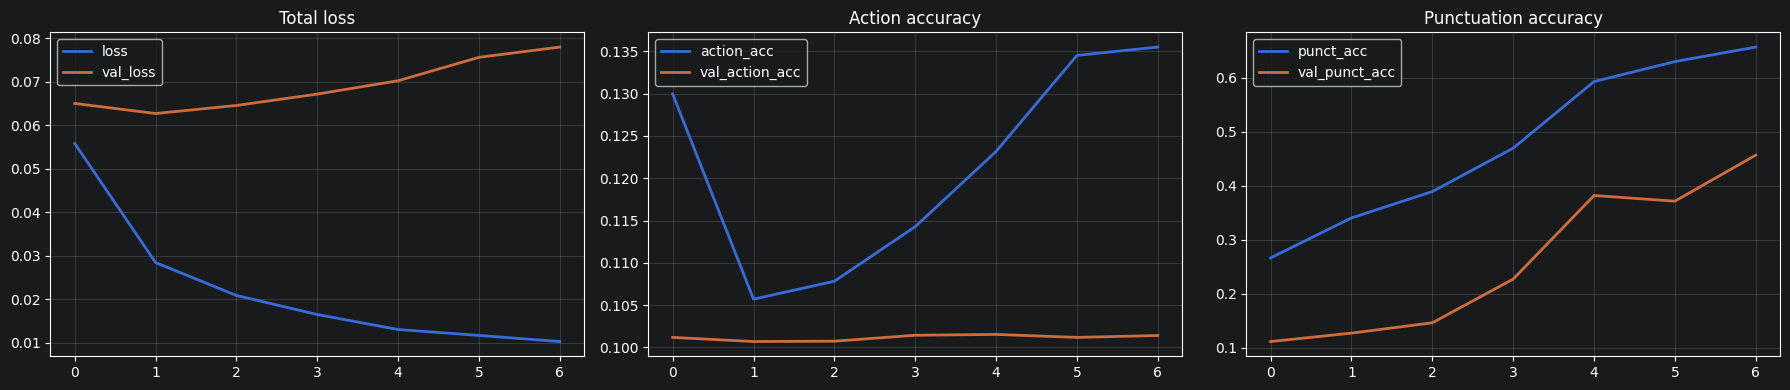

In [41]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0], linewidth=2)
axes[0].set_title("Total loss")
axes[0].grid(True, alpha=0.3)

for col in ["action_acc", "val_action_acc"]:
    if col in history_df:
        history_df[col].plot(ax=axes[1], linewidth=2, label=col)
axes[1].set_title("Action accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for col in ["punct_acc", "val_punct_acc"]:
    if col in history_df:
        history_df[col].plot(ax=axes[2], linewidth=2, label=col)
axes[2].set_title("Punctuation accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10.1 Evaluate


In [3]:
# Reload project modules before evaluation. This prevents stale Jupyter imports
# from trying to load a model with an old class definition.
reload_project_modules()

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing model config: {CONFIG_PATH}. Run training cell 16 first.")

model_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
if model_config.get("model_version", 0) < 11:
    raise RuntimeError(
        "The saved model is obsolete for the V11 runtime. "
        "Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again."
    )
if not model_config.get("requires_source_punct_ids", False) or not model_config.get("requires_top_k_candidates", False):
    raise RuntimeError(
        "The saved model is from an old input format. "
        "Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again."
    )

from evaluate_hybrid import evaluate_hybrid

summary = evaluate_hybrid(
    dataset_path=str(TEST_PATH),
    sample_size=EVAL_SAMPLE_SIZE,
    output_dir=str(EVAL_OUTPUT_DIR),
    strictness=STRICTNESS,
    punctuation_mode=PUNCTUATION_MODE,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    candidate_top_k=CANDIDATE_TOP_K,
    context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
    context_model_name=CONTEXT_MODEL_NAME,
    context_device=CONTEXT_DEVICE,
    context_margin=CONTEXT_MARGIN,
    use_entity_guard=USE_ENTITY_GUARD,
    write_diagnostics=WRITE_DIAGNOSTICS,
    inference_batch_size=INFERENCE_BATCH_SIZE,
)
summary


RuntimeError: The saved model is obsolete for the V11 runtime. Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again.

## 10.2 External Evaluation

Runs held-out real spellcheck/punctuation benchmarks without mixing them into the synthetic test split.


In [3]:
external_summaries = {}

if RUN_EXTERNAL_EVAL:
    external_eval_jobs = [
        ("ai_forever_sample", EXTERNAL_AI_FOREVER_PATH, "report/external_ai_forever_v11_sample", 1000),
        ("ai_forever_full", EXTERNAL_AI_FOREVER_PATH, "report/external_ai_forever_v11", None),
        ("ruspellgold", EXTERNAL_RUSPELLGOLD_PATH, "report/external_ruspellgold_v11", EXTERNAL_EVAL_SAMPLE_SIZE),
    ]
    for name, path, output_dir, sample_size in external_eval_jobs:
        if not Path(path).exists():
            print(f"External eval skipped for {name}: missing {path}")
            continue
        external_summaries[name] = evaluate_hybrid(
            dataset_path=str(path),
            sample_size=sample_size,
            output_dir=output_dir,
            strictness=STRICTNESS,
            punctuation_mode=PUNCTUATION_MODE,
            min_dictionary_score=MIN_DICTIONARY_SCORE,
            candidate_top_k=CANDIDATE_TOP_K,
            context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
            context_model_name=CONTEXT_MODEL_NAME,
            context_device=CONTEXT_DEVICE,
            context_margin=CONTEXT_MARGIN,
            use_entity_guard=USE_ENTITY_GUARD,
            write_diagnostics=WRITE_DIAGNOSTICS,
            inference_batch_size=INFERENCE_BATCH_SIZE,
        )
    display(pd.DataFrame(external_summaries).T) if external_summaries else print("External eval skipped.")
else:
    print("External eval disabled.")

External eval disabled.


## 10.3 FRED-T5 Test Subset Evaluation

Runs the requested FRED-T5 1.7B baseline on a sampled test subset and writes the same high-level quality reports to `report/fred_t5_test_v11_sample/`.


In [10]:
reload_project_modules(["evaluate_fred_t5"])
from evaluate_fred_t5 import evaluate_fred_t5

fred_t5_test_summary = {}

if RUN_FRED_T5_TEST_EVAL:
    fred_t5_test_summary = evaluate_fred_t5(
        dataset_path=str(TEST_PATH),
        split="test",
        sample_size=FRED_T5_TEST_SAMPLE_SIZE,
        output_dir=str(FRED_T5_TEST_OUTPUT_DIR),
        model_name=FRED_T5_MODEL_NAME,
        prompt_template=FRED_T5_PROMPT_TEMPLATE,
        device=FRED_T5_DEVICE,
        torch_dtype=FRED_T5_DTYPE,
        batch_size=FRED_T5_BATCH_SIZE,
        max_input_tokens=FRED_T5_MAX_INPUT_TOKENS,
        max_new_tokens=FRED_T5_MAX_NEW_TOKENS,
        use_dynamic_max_length=FRED_T5_USE_DYNAMIC_MAX_LENGTH,
        max_length_multiplier=FRED_T5_MAX_LENGTH_MULTIPLIER,
        num_beams=FRED_T5_NUM_BEAMS,
        repetition_penalty=FRED_T5_REPETITION_PENALTY,
        no_repeat_ngram_size=FRED_T5_NO_REPEAT_NGRAM_SIZE,
        length_penalty=FRED_T5_LENGTH_PENALTY,
        show_download_progress=FRED_T5_DOWNLOAD_PROGRESS,
    )
    display(pd.DataFrame([fred_t5_test_summary]))
else:
    print("FRED-T5 test eval disabled. Set RUN_FRED_T5_TEST_EVAL = True in config cell 4.")


Preparing Hugging Face model cache: ai-forever/sage-fredt5-large
Downloading/checking config.json (unknown size)
Downloading/checking generation_config.json (unknown size)
Downloading/checking tokenizer_config.json (unknown size)
Downloading/checking special_tokens_map.json (unknown size)
Downloading/checking added_tokens.json (unknown size)
Downloading/checking vocab.json (unknown size)
Downloading/checking merges.txt (unknown size)
Downloading/checking model.safetensors (3.06 GiB)


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

FRED-T5 evaluation:   0%|          | 0/200 [00:00<?, ?it/s]

FRED-T5 evaluated 1/200 examples
FRED-T5 evaluated 2/200 examples
FRED-T5 evaluated 3/200 examples
FRED-T5 evaluated 4/200 examples
FRED-T5 evaluated 5/200 examples
FRED-T5 evaluated 6/200 examples
FRED-T5 evaluated 7/200 examples
FRED-T5 evaluated 8/200 examples
FRED-T5 evaluated 9/200 examples
FRED-T5 evaluated 10/200 examples
FRED-T5 evaluated 11/200 examples
FRED-T5 evaluated 12/200 examples
FRED-T5 evaluated 13/200 examples
FRED-T5 evaluated 14/200 examples
FRED-T5 evaluated 15/200 examples
FRED-T5 evaluated 16/200 examples
FRED-T5 evaluated 17/200 examples
FRED-T5 evaluated 18/200 examples
FRED-T5 evaluated 19/200 examples
FRED-T5 evaluated 20/200 examples
FRED-T5 evaluated 21/200 examples
FRED-T5 evaluated 22/200 examples
FRED-T5 evaluated 23/200 examples
FRED-T5 evaluated 24/200 examples
FRED-T5 evaluated 25/200 examples
FRED-T5 evaluated 26/200 examples
FRED-T5 evaluated 27/200 examples
FRED-T5 evaluated 28/200 examples
FRED-T5 evaluated 29/200 examples
FRED-T5 evaluated 30/20

,examples,exact_match,mean_input_cer,mean_pred_cer,mean_cer_delta,improved_rate,worse_rate,unchanged_rate,unchanged_wrong_rate,clean_overcorrection_rate,...,download_progress,model_source,local_files_only,runtime_version,dataset_path,split,sample_size,elapsed_minutes,source_kind_slices,source_dataset_slices
0,200,0.095,0.011297,0.017662,-0.006365,0.155,0.49,0.075,0.061538,0.9,...,True,ai-forever/sage-fredt5-large,True,fred_t5_baseline_v1,data/processed/test.csv,test,200,2.418567,"{'synthetic': {'examples': 200, 'exact_match':...","{'curated_v10': {'examples': 3, 'exact_match':..."


## 10.4 FRED-T5 External Evaluation

Runs the FRED-T5 baseline on the two external evaluation datasets already used by the project: AI Forever spellcheck/punctuation benchmark and RuSpellGold.


In [7]:
reload_project_modules(["evaluate_fred_t5"])
from evaluate_fred_t5 import evaluate_fred_t5

fred_t5_external_summaries = {}

if RUN_FRED_T5_EXTERNAL_EVAL:
    fred_t5_external_jobs = [
        ("ai_forever", EXTERNAL_AI_FOREVER_PATH, FRED_T5_EXTERNAL_AI_FOREVER_OUTPUT_DIR),
        ("ruspellgold", EXTERNAL_RUSPELLGOLD_PATH, FRED_T5_EXTERNAL_RUSPELLGOLD_OUTPUT_DIR),
    ]
    for name, path, output_dir in fred_t5_external_jobs:
        if not Path(path).exists():
            print(f"FRED-T5 external eval skipped for {name}: missing {path}")
            continue
        fred_t5_external_summaries[name] = evaluate_fred_t5(
            dataset_path=str(path),
            split="test",
            sample_size=FRED_T5_EXTERNAL_EVAL_SAMPLE_SIZE,
            output_dir=str(output_dir),
            model_name=FRED_T5_MODEL_NAME,
            prompt_template=FRED_T5_PROMPT_TEMPLATE,
            device=FRED_T5_DEVICE,
            torch_dtype=FRED_T5_DTYPE,
            batch_size=FRED_T5_BATCH_SIZE,
            max_input_tokens=FRED_T5_MAX_INPUT_TOKENS,
            max_new_tokens=FRED_T5_MAX_NEW_TOKENS,
            use_dynamic_max_length=FRED_T5_USE_DYNAMIC_MAX_LENGTH,
            max_length_multiplier=FRED_T5_MAX_LENGTH_MULTIPLIER,
            num_beams=FRED_T5_NUM_BEAMS,
        repetition_penalty=FRED_T5_REPETITION_PENALTY,
        no_repeat_ngram_size=FRED_T5_NO_REPEAT_NGRAM_SIZE,
        length_penalty=FRED_T5_LENGTH_PENALTY,
            show_download_progress=FRED_T5_DOWNLOAD_PROGRESS,
        )
    display(pd.DataFrame(fred_t5_external_summaries).T) if fred_t5_external_summaries else print("FRED-T5 external eval skipped.")
else:
    print("FRED-T5 external eval disabled. Set RUN_FRED_T5_EXTERNAL_EVAL = True in config cell 4.")


Preparing Hugging Face model cache: ai-forever/sage-fredt5-large
Downloading/checking config.json (unknown size)
Downloading/checking generation_config.json (unknown size)
Downloading/checking tokenizer_config.json (unknown size)
Downloading/checking special_tokens_map.json (unknown size)
Downloading/checking added_tokens.json (unknown size)
Downloading/checking vocab.json (unknown size)
Downloading/checking merges.txt (unknown size)
Downloading/checking model.safetensors (3.06 GiB)


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

FRED-T5 evaluation:   0%|          | 0/200 [00:00<?, ?it/s]

FRED-T5 evaluated 1/200 examples
FRED-T5 evaluated 2/200 examples
FRED-T5 evaluated 3/200 examples
FRED-T5 evaluated 4/200 examples
FRED-T5 evaluated 5/200 examples
FRED-T5 evaluated 6/200 examples
FRED-T5 evaluated 7/200 examples
FRED-T5 evaluated 8/200 examples
FRED-T5 evaluated 9/200 examples
FRED-T5 evaluated 10/200 examples
FRED-T5 evaluated 11/200 examples
FRED-T5 evaluated 12/200 examples
FRED-T5 evaluated 13/200 examples
FRED-T5 evaluated 14/200 examples
FRED-T5 evaluated 15/200 examples
FRED-T5 evaluated 16/200 examples
FRED-T5 evaluated 17/200 examples
FRED-T5 evaluated 18/200 examples
FRED-T5 evaluated 19/200 examples
FRED-T5 evaluated 20/200 examples
FRED-T5 evaluated 21/200 examples
FRED-T5 evaluated 22/200 examples
FRED-T5 evaluated 23/200 examples
FRED-T5 evaluated 24/200 examples
FRED-T5 evaluated 25/200 examples
FRED-T5 evaluated 26/200 examples
FRED-T5 evaluated 27/200 examples
FRED-T5 evaluated 28/200 examples
FRED-T5 evaluated 29/200 examples
FRED-T5 evaluated 30/20

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

FRED-T5 evaluation:   0%|          | 0/200 [00:00<?, ?it/s]

FRED-T5 evaluated 1/200 examples
FRED-T5 evaluated 2/200 examples
FRED-T5 evaluated 3/200 examples
FRED-T5 evaluated 4/200 examples
FRED-T5 evaluated 5/200 examples
FRED-T5 evaluated 6/200 examples
FRED-T5 evaluated 7/200 examples
FRED-T5 evaluated 8/200 examples
FRED-T5 evaluated 9/200 examples
FRED-T5 evaluated 10/200 examples
FRED-T5 evaluated 11/200 examples
FRED-T5 evaluated 12/200 examples
FRED-T5 evaluated 13/200 examples
FRED-T5 evaluated 14/200 examples
FRED-T5 evaluated 15/200 examples
FRED-T5 evaluated 16/200 examples
FRED-T5 evaluated 17/200 examples
FRED-T5 evaluated 18/200 examples
FRED-T5 evaluated 19/200 examples
FRED-T5 evaluated 20/200 examples
FRED-T5 evaluated 21/200 examples
FRED-T5 evaluated 22/200 examples
FRED-T5 evaluated 23/200 examples
FRED-T5 evaluated 24/200 examples
FRED-T5 evaluated 25/200 examples
FRED-T5 evaluated 26/200 examples
FRED-T5 evaluated 27/200 examples
FRED-T5 evaluated 28/200 examples
FRED-T5 evaluated 29/200 examples
FRED-T5 evaluated 30/20

,examples,exact_match,mean_input_cer,mean_pred_cer,mean_cer_delta,improved_rate,worse_rate,unchanged_rate,unchanged_wrong_rate,clean_overcorrection_rate,...,download_progress,model_source,local_files_only,runtime_version,dataset_path,split,sample_size,elapsed_minutes,source_kind_slices,source_dataset_slices
ai_forever,200,0.13,0.059354,0.047586,0.011768,0.555,0.275,0.03,0.03,None,...,True,ai-forever/sage-fredt5-large,True,fred_t5_baseline_v1,data/external/ai_forever_spellcheck_punctuatio...,test,200,2.428493,"{'real': {'examples': 200, 'exact_match': 0.13...",{'ai-forever/spellcheck_punctuation_benchmark:...
ruspellgold,200,0.07,0.018507,0.029663,-0.011156,0.165,0.565,0.005,0.005,None,...,True,ai-forever/sage-fredt5-large,True,fred_t5_baseline_v1,data/external/ruspellgold_test.csv,test,200,3.351351,"{'real': {'examples': 200, 'exact_match': 0.07...",{'RussianNLP/RuSpellGold:RuSpellGold:test': {'...


## 11. Analyze Reports

In [5]:
summary_path = EVAL_OUTPUT_DIR / "summary.json"
analysis_path = EVAL_OUTPUT_DIR / "error_analysis.csv"
by_type_path = EVAL_OUTPUT_DIR / "error_metrics_by_type.csv"
worst_path = EVAL_OUTPUT_DIR / "worst_cases.csv"
punct_diag_path = EVAL_OUTPUT_DIR / "punct_edit_diagnostics.csv"
word_decision_path = EVAL_OUTPUT_DIR / "word_decision_diagnostics.csv"

if summary_path.exists():
    print(summary_path.read_text(encoding="utf-8"))

analysis_df = pd.read_csv(analysis_path) if analysis_path.exists() else pd.DataFrame()
by_type_df = pd.read_csv(by_type_path) if by_type_path.exists() else pd.DataFrame()
worst_df = pd.read_csv(worst_path) if worst_path.exists() else pd.DataFrame()
punct_diag_df = pd.read_csv(punct_diag_path) if punct_diag_path.exists() else pd.DataFrame()
word_decision_df = pd.read_csv(word_decision_path) if word_decision_path.exists() else pd.DataFrame()

print("Analysis rows:", len(analysis_df))
if not analysis_df.empty:
    clean_df = analysis_df[analysis_df["input_cer"] == 0]
    dirty_df = analysis_df[analysis_df["input_cer"] > 0]
    quality_rows = []
    for name, part in [("clean", clean_df), ("dirty", dirty_df), ("all", analysis_df)]:
        if part.empty:
            continue
        quality_rows.append({
            "slice": name,
            "examples": len(part),
            "mean_input_cer": part["input_cer"].mean(),
            "mean_pred_cer": part["pred_cer"].mean(),
            "mean_cer_delta": part["cer_delta"].mean(),
            "worse_rate": part["worse"].mean(),
            "clean_overcorrection_rate": part["clean_overcorrection"].mean() if name == "clean" else np.nan,
            "word_overcorrection_rate": part["word_overcorrection"].mean() if name == "clean" and "word_overcorrection" in part else np.nan,
            "punct_overcorrection_rate": part["punct_overcorrection"].mean() if name == "clean" and "punct_overcorrection" in part else np.nan,
            "layout_changed_without_edits": part["layout_changed_without_edits"].sum() if "layout_changed_without_edits" in part else np.nan,
            "punct_similarity_delta": part["punct_pred_similarity"].mean() - part["punct_input_similarity"].mean(),
            "accepted_rate": part["accepted"].mean(),
        })
    display(pd.DataFrame(quality_rows))

if not by_type_df.empty:
    display(by_type_df.head(20))
if not worst_df.empty:
    columns = [
        "error_types", "input_cer", "pred_cer", "cer_delta", "guard_reason",
        "word_edit_count", "punct_edit_count", "error_text", "predicted_text", "correct_text",
    ]
    display(worst_df[[c for c in columns if c in worst_df.columns]].head(20))


if not word_decision_df.empty:
    print("Word decision diagnostics rows:", len(word_decision_df))
    display(word_decision_df["blocked_reason"].value_counts(dropna=False).head(20).to_frame("count"))
    if "target_present_but_not_applied" in word_decision_df:
        display(word_decision_df[word_decision_df["target_present_but_not_applied"] == True].head(20))
    display(word_decision_df.head(20))

if not punct_diag_df.empty:
    print("Punctuation diagnostics rows:", len(punct_diag_df))
    display(punct_diag_df["blocked_reason"].value_counts(dropna=False).head(20).to_frame("count"))
    for column in ["protected_gap", "punct_position_type", "window_conflict_resolved"]:
        if column in punct_diag_df:
            display(punct_diag_df[column].value_counts(dropna=False).head(10).to_frame("count"))
    display(punct_diag_df.head(20))

print("Full test command after training:")
print(
    "PYTHONPATH=src .venv/bin/python src/evaluate.py "
    "--dataset data/processed/test.csv --all --output-dir report/synthetic_v11 "
    "--strictness strict --punctuation-mode conservative --candidate-top-k 16 "
    "--context-device auto --no-diagnostics --inference-batch-size 512"
)

# V11 comparison table: keep old V10.5 summaries next to fresh V11 runs.
summary_jobs = {
    "synthetic_v10_5": Path("report/synthetic_v10_5/summary.json"),
    "synthetic_v11": Path("report/synthetic_v11/summary.json"),
    "ai_forever_v10_5_sample": Path("report/external_ai_forever_v10_5_sample/summary.json"),
    "ai_forever_v11_sample": Path("report/external_ai_forever_v11_sample/summary.json"),
    "ai_forever_v11_full": Path("report/external_ai_forever_v11/summary.json"),
    "ruspellgold_v10_5": Path("report/external_ruspellgold_v10_5/summary.json"),
    "ruspellgold_v11": Path("report/external_ruspellgold_v11/summary.json"),
    "fred_t5_test_v11_sample": FRED_T5_TEST_OUTPUT_DIR / "summary.json",
    "fred_t5_ai_forever_v11_sample": FRED_T5_EXTERNAL_AI_FOREVER_OUTPUT_DIR / "summary.json",
    "fred_t5_ruspellgold_v11_sample": FRED_T5_EXTERNAL_RUSPELLGOLD_OUTPUT_DIR / "summary.json",
}
comparison_rows = []
for name, path in summary_jobs.items():
    if not path.exists():
        continue
    item = json.loads(path.read_text(encoding="utf-8"))
    comparison_rows.append({
        "run": name,
        "runtime_version": item.get("runtime_version"),
        "model_name": item.get("model_name", "hybrid"),
        "examples": item.get("examples"),
        "exact_match": item.get("exact_match"),
        "mean_cer_delta": item.get("mean_cer_delta"),
        "improved_rate": item.get("improved_rate"),
        "worse_rate": item.get("worse_rate"),
        "candidate_coverage_rate": item.get("candidate_coverage_rate"),
        "target_present_but_not_applied_rate": item.get("target_present_but_not_applied_rate"),
        "clean_overcorrection_rate": item.get("clean_overcorrection_rate"),
        "word_overcorrection_rate": item.get("word_overcorrection_rate"),
        "punct_overcorrection_rate": item.get("punct_overcorrection_rate"),
        "generation_empty_rate": item.get("generation_empty_rate"),
        "input_fallback_rate": item.get("input_fallback_rate"),
    })
if comparison_rows:
    display(pd.DataFrame(comparison_rows))

if not word_decision_df.empty:
    target_absent = word_decision_df[(word_decision_df["target_is_replace"] == True) & (word_decision_df["target_present"] == False)]
    target_blocked = word_decision_df[word_decision_df.get("target_present_but_not_applied", False) == True]
    wrong_split = word_decision_df[word_decision_df["candidate_sources"].astype(str).str.contains("split|phrase_safe", regex=True, na=False)]
    for title, frame in [
        ("target absent", target_absent),
        ("target present but blocked", target_blocked),
        ("split/phrase-safe decisions", wrong_split),
    ]:
        print(title, len(frame))
        display(frame.head(20))

if not punct_diag_df.empty:
    punct_regressions = punct_diag_df[(punct_diag_df["row_worse"] == True) & (punct_diag_df["applied"] == True)]
    print("punctuation regression decisions", len(punct_regressions))
    display(punct_regressions.head(20))

{
  "examples": 5931,
  "exact_match": 0.5727533299612207,
  "mean_input_cer": 0.011483649000945931,
  "mean_pred_cer": 0.0077596974160932634,
  "mean_cer_delta": 0.0037239515848526703,
  "improved_rate": 0.2633619962906761,
  "worse_rate": 0.002697690102849435,
  "unchanged_rate": 0.7303995953464846,
  "unchanged_wrong_rate": 0.5861801242236024,
  "clean_overcorrection_rate": 0.0,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.0,
  "punct_input_similarity": 0.8880402631934953,
  "punct_pred_similarity": 0.9184311082277392,
  "punct_similarity_delta": 0.03039084503424394,
  "mean_punct_count_error": 0.4371944022930366,
  "mean_confidence": 0.9816990415203781,
  "accepted_rate": 0.9313775080087675,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 2067,
    "exact_match": 1.0,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.0,
    "mean_cer_delta": 0.0,
    "improved_rate": 0.0,
    "worse_rate": 0.0,
    "unchanged_rate": 1.0,
    "unc

,slice,examples,mean_input_cer,mean_pred_cer,mean_cer_delta,worse_rate,clean_overcorrection_rate,word_overcorrection_rate,punct_overcorrection_rate,layout_changed_without_edits,punct_similarity_delta,accepted_rate
0,clean,2067,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0.000000,0.992743
1,dirty,3864,0.017627,0.011911,0.005716,0.004141,NaN,NaN,NaN,0,0.046648,0.898551
2,all,5931,0.011484,0.007760,0.003724,0.002698,NaN,NaN,NaN,0,0.030391,0.931378


,examples,exact_match,mean_input_cer,mean_pred_cer,mean_cer_delta,improved_rate,worse_rate,unchanged_rate,unchanged_wrong_rate,clean_overcorrection_rate,word_overcorrection_rate,punct_overcorrection_rate,punct_input_similarity,punct_pred_similarity,punct_similarity_delta,mean_punct_count_error,mean_confidence,accepted_rate,layout_changed_without_edits_count,error_type
0,2067,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,0.0,0.0,0.0,1.000000,1.000000,0.000000,0.000000,0.984346,0.992743,0,clean
1,9,0.000000,0.031030,0.031030,0.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN,NaN,0.745679,0.745679,0.000000,1.000000,0.970940,1.000000,0,punct_dash_extra
2,87,0.057471,0.016776,0.015646,0.001131,0.114943,0.000000,0.885057,0.885057,NaN,NaN,NaN,0.752374,0.767445,0.015070,1.333333,0.981968,0.885057,0,punct_remove_comma_before_clause
3,11,0.000000,0.031866,0.030423,0.001443,0.090909,0.000000,0.909091,0.909091,NaN,NaN,NaN,0.829946,0.829946,0.000000,1.090909,0.975352,1.000000,0,punct_dash_missing
4,38,0.000000,0.028370,0.026584,0.001786,0.157895,0.000000,0.842105,0.842105,NaN,NaN,NaN,0.511457,0.510300,-0.001157,4.342105,0.983997,1.000000,0,punct_quote_style
5,44,0.045455,0.015108,0.012847,0.002261,0.181818,0.000000,0.818182,0.818182,NaN,NaN,NaN,0.701604,0.720002,0.018398,1.090909,0.985396,1.000000,0,punct_remove_all_commas
6,95,0.000000,0.019577,0.017258,0.002319,0.105263,0.010526,0.884211,0.884211,NaN,NaN,NaN,0.748348,0.755767,0.007419,1.242105,0.978912,0.947368,0,punct_remove_internal_comma
7,45,0.177778,0.015157,0.012741,0.002416,0.222222,0.000000,0.777778,0.777778,NaN,NaN,NaN,0.654010,0.730677,0.076667,1.800000,0.982378,0.777778,0,punct_wrong_comma_to_period
8,33,0.000000,0.031589,0.028729,0.002860,0.151515,0.000000,0.848485,0.848485,NaN,NaN,NaN,0.637524,0.640554,0.003030,2.454545,0.980172,0.909091,0,punct_remove_quotes
9,521,0.046065,0.025228,0.021668,0.003561,0.193858,0.000000,0.806142,0.806142,NaN,NaN,NaN,0.735892,0.752875,0.016983,1.433781,0.980075,0.905950,0,punct_extra_comma


,error_types,input_cer,pred_cer,cer_delta,guard_reason,word_edit_count,punct_edit_count,error_text,predicted_text,correct_text
0,spelling_replace,0.012658,0.037975,-0.025316,accepted,1,0,"Элементы сложные, удаление их направлено на уп...","Элементы сложные, удаление их направлено на уп...","Элементы сложные, удаление их направлено на уп..."
1,spelling_double,0.023256,0.046512,-0.023256,accepted,1,0,приветствует своего поччтенного господина А.,приветствует своего поччтенново господина А.,приветствует своего почтенного господина А.
2,spelling_extra,0.021277,0.042553,-0.021277,accepted,1,0,Двоих остававшихся в нем жильцов уже врасселили.,Двоих остававшихся в нем жильцов уже в расселили.,Двоих остававшихся в нем жильцов уже расселили.
3,spelling_double,0.020000,0.040000,-0.020000,accepted,1,0,Не зря же во всем мире к нему ссейчас возвраща...,Не зря же во всем мире к нему с сейчас возвращ...,Не зря же во всем мире к нему сейчас возвращаю...
4,spelling_delete,0.038462,0.057692,-0.019231,accepted,0,1,Роспект Просвещения) у вас будет такая возможн...,Роспект Просвещения у вас будет такая возможно...,Проспект Просвещения) у вас будет такая возмож...
5,spelling_delete,0.015625,0.031250,-0.015625,accepted,1,0,Zivert до недавнего времени тоже олучала около...,Zivert до недавнего времени тоже обучала около...,Zivert до недавнего времени тоже получала окол...
6,spelling_replace,0.011494,0.022989,-0.011494,accepted,1,0,Сегодня норозный антициклон останется полновла...,Сегодня грозный антициклон останется полновлас...,Сегодня морозный антициклон останется полновла...
7,spelling_double,0.010989,0.021978,-0.010989,accepted,1,0,"Ученый добавил, что в первую неделю уровень во...","Ученый добавил, что в первую неделю уровень во...","Ученый добавил, что в первую неделю уровень во..."
8,spelling_replace|spelling_replace,0.019231,0.028846,-0.009615,accepted,1,0,"Бывают и неханические повреждения: прорывы, за...","Бывают и технические повреждения: прорывы, зат...","Бывают и механические повреждения: прорывы, за..."
9,spelling_double,0.009174,0.018349,-0.009174,accepted,1,0,"В дороге один из них, ккоторому на вид лет 16,...","В дороге один из них, к которому на вид лет 16...","В дороге один из них, которому на вид лет 16, ..."


Word decision diagnostics rows: 15296


...

,count
protected_gap,
False,81297
True,1216


,count
punct_position_type,
internal,75551
final,5746
protected,1216


,count
window_conflict_resolved,
False,82513


,row_index,difficulty,error_types,is_clean,row_improved,row_worse,row_unchanged,index,word,source_punct,...,applied,blocked_reason,is_final,protected_gap,punct_position_type,window_id,window_conflict_resolved,text,predicted,target_text
0,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,0,Перевод,":""",...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
1,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,1,4,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
2,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,2,деккабря,(,...,False,low_confidence_or_margin,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
3,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,3,Святиополк,NaN,...,False,same_as_source,False,True,protected,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
4,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,4,Владемир,",",...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
5,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,5,и,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
6,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,6,Олег,(,...,False,low_confidence_or_margin,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
7,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,7,заключили,),...,True,applied,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
8,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,8,нир,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
9,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,9,на,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 деккабря (Святиополк), Владемир, и...","Перевод: ""4 декабря Святополк, Владимир и Олег..."


Full test command after training:
PYTHONPATH=src .venv/bin/python src/evaluate.py --dataset data/processed/test.csv --all --output-dir report/synthetic_v11 --strictness strict --punctuation-mode conservative --candidate-top-k 16 --context-device auto --no-diagnostics --inference-batch-size 512


## 12. Manual Runtime Checks

In [6]:
from hybrid_corrector import HybridCorrector

corrector = HybridCorrector(strictness=STRICTNESS, punctuation_mode=PUNCTUATION_MODE, min_dictionary_score=MIN_DICTIONARY_SCORE, context_reranker_enabled=CONTEXT_RERANKER_ENABLED, context_model_name=CONTEXT_MODEL_NAME, context_device=CONTEXT_DEVICE, candidate_top_k=CANDIDATE_TOP_K, context_margin=CONTEXT_MARGIN, use_entity_guard=USE_ENTITY_GUARD)
print("Model trained:", corrector.is_trained)

sample_df = globals().get("df_test")
if sample_df is None:
    if not TEST_PATH.exists():
        raise FileNotFoundError(f"Missing test split: {TEST_PATH}. Run dataset preparation or training first.")
    sample_df = pd.read_csv(TEST_PATH)
    if "split" in sample_df.columns:
        sample_df = sample_df[sample_df["split"] == "test"].copy()
    print("Loaded test samples from disk:", len(sample_df))

if len(sample_df) > 0:
    sample_rows = sample_df.sample(min(5, len(sample_df)), random_state=SEED)
    for i, row in sample_rows.iterrows():
        result = corrector.correct(str(row["error_text"]), return_details=True)
        print("=" * 80)
        print("ERROR:  ", row["error_text"])
        print("PRED:   ", result.corrected)
        print("TARGET: ", row["correct_text"])
        print("confidence:", round(result.confidence, 3), "accepted:", result.accepted, "reason:", result.guard_reason)
        print("edits:", result.edits[:8])


Model trained: True
Loaded test samples from disk: 5931
ERROR:   Первые сообщения о двойном убийстве появились в московских и петербургских изданиях вскоре после преступления; потом вышли заметки о том, что злоумышленник схвачен.
PRED:    Первые сообщения о двойном убийстве появились в московских и петербургских изданиях вскоре после преступления; потом вышли заметки о том, что злоумышленник схвачен.
TARGET:  Первые сообщения о двойном убийстве появились в московских и петербургских изданиях вскоре после преступления; потом вышли заметки о том, что злоумышленник схвачен.
confidence: 0.995 accepted: True reason: accepted
edits: []
ERROR:   В результате боя российские военные взали несколько украинцев в плен.
PRED:    В результате боя российские военные взяли несколько украинцев в плен.
TARGET:  В результате боя российские военные взяли несколько украинцев в плен.
confidence: 0.996 accepted: True reason: accepted
edits: [CorrectionEdit(index=5, source='взали', target='взяли', action='REP

## 13. Strictness Comparison (Optional)

This can be slow because it runs inference several times. Reduce `sample_size` if needed.


In [24]:
from evaluate_hybrid import evaluate_hybrid

RUN_STRICTNESS_COMPARISON = True
COMPARISON_SAMPLE_SIZE = 100

if RUN_STRICTNESS_COMPARISON:
    rows = []
    for mode in ["strict", "normal", "aggressive"]:
        result = evaluate_hybrid(
            dataset_path=str(TEST_PATH),
            sample_size=COMPARISON_SAMPLE_SIZE,
            output_dir=f"report/strictness_{mode}",
            strictness=mode,
            punctuation_mode=PUNCTUATION_MODE,
            min_dictionary_score=MIN_DICTIONARY_SCORE,
            candidate_top_k=CANDIDATE_TOP_K,
            context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
            context_model_name=CONTEXT_MODEL_NAME,
            context_device=CONTEXT_DEVICE,
            context_margin=CONTEXT_MARGIN,
            use_entity_guard=USE_ENTITY_GUARD,
            write_diagnostics=WRITE_DIAGNOSTICS,
            inference_batch_size=INFERENCE_BATCH_SIZE,
        )
        result["strictness"] = mode
        rows.append(result)
    comparison_df = pd.DataFrame(rows)
    display(comparison_df[["strictness", "mean_pred_cer", "mean_cer_delta", "worse_rate", "clean_overcorrection_rate", "accepted_rate"]])
else:
    print("Strictness comparison skipped.")


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 100/100 examples
Evaluated 50/100 examples
Evaluated 100/100 examples
{
  "examples": 100,
  "exact_match": 0.64,
  "mean_input_cer": 0.010588369863425116,
  "mean_pred_cer": 0.00645425489119331,
  "mean_cer_delta": 0.004134114972231807,
  "improved_rate": 0.29,
  "worse_rate": 0.0,
  "unchanged_rate": 0.7,
  "unchanged_wrong_rate": 0.5,
  "clean_overcorrection_rate": 0.0,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.0,
  "punct_input_similarity": 0.9158131313131312,
  "punct_pred_similarity": 0.9410512265512265,
  "punct_similarity_delta": 0.02523809523809528,
  "mean_punct_count_error": 0.31,
  "mean_confidence": 0.9810131294826884,
  "accepted_rate": 0.94,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 40,
    "exact_match": 1.0,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.0,
    "mean_cer_delta": 0.0,
    "improved_rate": 0.0,
    "worse_rate": 0.0,
    "unchanged_rate": 1.0,
    "unchanged_wrong_rate": null,
   

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 100/100 examples
Evaluated 50/100 examples
Evaluated 100/100 examples
{
  "examples": 100,
  "exact_match": 0.64,
  "mean_input_cer": 0.010588369863425116,
  "mean_pred_cer": 0.006689158465041134,
  "mean_cer_delta": 0.003899211398383984,
  "improved_rate": 0.28,
  "worse_rate": 0.0,
  "unchanged_rate": 0.71,
  "unchanged_wrong_rate": 0.5166666666666667,
  "clean_overcorrection_rate": 0.0,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.0,
  "punct_input_similarity": 0.9158131313131312,
  "punct_pred_similarity": 0.9443845598845598,
  "punct_similarity_delta": 0.02857142857142858,
  "mean_punct_count_error": 0.29,
  "mean_confidence": 0.9810131294826884,
  "accepted_rate": 0.94,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 40,
    "exact_match": 1.0,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.0,
    "mean_cer_delta": 0.0,
    "improved_rate": 0.0,
    "worse_rate": 0.0,
    "unchanged_rate": 1.0,
    "unchanged_wrong

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 100/100 examples
Evaluated 50/100 examples
Evaluated 100/100 examples
{
  "examples": 100,
  "exact_match": 0.68,
  "mean_input_cer": 0.010588369863425116,
  "mean_pred_cer": 0.005920654391118341,
  "mean_cer_delta": 0.004667715472306776,
  "improved_rate": 0.32,
  "worse_rate": 0.0,
  "unchanged_rate": 0.67,
  "unchanged_wrong_rate": 0.45,
  "clean_overcorrection_rate": 0.0,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.0,
  "punct_input_similarity": 0.9158131313131312,
  "punct_pred_similarity": 0.9538290043290044,
  "punct_similarity_delta": 0.03801587301587317,
  "mean_punct_count_error": 0.24,
  "mean_confidence": 0.9810131294826884,
  "accepted_rate": 0.94,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 40,
    "exact_match": 1.0,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.0,
    "mean_cer_delta": 0.0,
    "improved_rate": 0.0,
    "worse_rate": 0.0,
    "unchanged_rate": 1.0,
    "unchanged_wrong_rate": null,


,strictness,mean_pred_cer,mean_cer_delta,worse_rate,clean_overcorrection_rate,accepted_rate
0,strict,0.006454,0.004134,0.0,0.0,0.94
1,normal,0.006689,0.003899,0.0,0.0,0.94
2,aggressive,0.005921,0.004668,0.0,0.0,0.94


## 14. GUI

After training, the desktop app uses the same `HybridCorrector` artifacts from `models/`.

```bash
PYTHONPATH=src .venv/bin/python app/main.py
```


In [16]:
from evaluate_fred_t5 import generate_predictions
from hybrid_corrector import HybridCorrector

my_text = "Привит друг"

hybrid_corrector = globals().get("corrector")
if hybrid_corrector is None or not isinstance(hybrid_corrector, HybridCorrector):
    hybrid_corrector = HybridCorrector(
        strictness=STRICTNESS,
        punctuation_mode=PUNCTUATION_MODE,
        min_dictionary_score=MIN_DICTIONARY_SCORE,
        context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
        context_model_name=CONTEXT_MODEL_NAME,
        context_device=CONTEXT_DEVICE,
        candidate_top_k=CANDIDATE_TOP_K,
        context_margin=CONTEXT_MARGIN,
        use_entity_guard=USE_ENTITY_GUARD,
    )

fred_predictions, _ = generate_predictions(
    [my_text],
    model_name=FRED_T5_MODEL_NAME,
    prompt_template=FRED_T5_PROMPT_TEMPLATE,
    device=FRED_T5_DEVICE,
    torch_dtype=FRED_T5_DTYPE,
    batch_size=1,
    max_input_tokens=FRED_T5_MAX_INPUT_TOKENS,
    max_new_tokens=FRED_T5_MAX_NEW_TOKENS,
    use_dynamic_max_length=FRED_T5_USE_DYNAMIC_MAX_LENGTH,
    max_length_multiplier=FRED_T5_MAX_LENGTH_MULTIPLIER,
    num_beams=FRED_T5_NUM_BEAMS,
    repetition_penalty=FRED_T5_REPETITION_PENALTY,
    no_repeat_ngram_size=FRED_T5_NO_REPEAT_NGRAM_SIZE,
    length_penalty=FRED_T5_LENGTH_PENALTY,
)

hybrid_result = hybrid_corrector.correct(my_text, return_details=True)

print("INPUT:")
print(my_text)
print()

print(f"{FRED_T5_MODEL_NAME}:")
print(fred_predictions[0].predicted_text)
print()

print("MY HYBRID TRANSFORMER:")
print(hybrid_result.corrected)
print("confidence:", round(hybrid_result.confidence, 3))
print("accepted:", hybrid_result.accepted)
print("reason:", hybrid_result.guard_reason)
print("edits:", hybrid_result.edits[:8])


Preparing Hugging Face model cache: ai-forever/sage-fredt5-large
Downloading/checking config.json (unknown size)
Downloading/checking generation_config.json (unknown size)
Downloading/checking tokenizer_config.json (unknown size)
Downloading/checking special_tokens_map.json (unknown size)
Downloading/checking added_tokens.json (unknown size)
Downloading/checking vocab.json (unknown size)
Downloading/checking merges.txt (unknown size)
Downloading/checking model.safetensors (3.06 GiB)


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

FRED-T5 evaluation:   0%|          | 0/1 [00:00<?, ?it/s]

FRED-T5 evaluated 1/1 examples
INPUT:
Привит друг

ai-forever/sage-fredt5-large:
Привет друг

MY HYBRID TRANSFORMER:
Привит друг
confidence: 0.756
accepted: True
reason: accepted
edits: []


In [17]:
from pathlib import Path

if "reload_project_modules" in globals():
    reload_project_modules(["hf_style_metrics"])
from hf_style_metrics import evaluate_hybrid_ai_forever_benchmark_hf_style

HYBRID_AI_FOREVER_BENCHMARK_OUTPUT_DIR = Path("report/hybrid_ai_forever_benchmark_hf_style")

hybrid_ai_forever_metrics_df, hybrid_ai_forever_predictions_df = evaluate_hybrid_ai_forever_benchmark_hf_style(
    output_dir=HYBRID_AI_FOREVER_BENCHMARK_OUTPUT_DIR,
    cache_dir=EXTERNAL_DATA_DIR,
    strictness=STRICTNESS,
    punctuation_mode=PUNCTUATION_MODE,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    use_morphology_guard=globals().get("USE_MORPHOLOGY_GUARD", True),
    candidate_top_k=CANDIDATE_TOP_K,
    context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
    context_model_name=CONTEXT_MODEL_NAME,
    context_device=CONTEXT_DEVICE,
    context_margin=CONTEXT_MARGIN,
    use_entity_guard=USE_ENTITY_GUARD,
    inference_batch_size=INFERENCE_BATCH_SIZE,
)

display(hybrid_ai_forever_metrics_df)
print("Predictions:", HYBRID_AI_FOREVER_BENCHMARK_OUTPUT_DIR / "predictions.csv")
print("Metrics CSV:", HYBRID_AI_FOREVER_BENCHMARK_OUTPUT_DIR / "metrics.csv")
print("Metrics JSON:", HYBRID_AI_FOREVER_BENCHMARK_OUTPUT_DIR / "metrics.json")


RUSpellRU: loaded 2008 examples from ai-forever/spellcheck_punctuation_benchmark/data/RUSpellRU/test.json


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

RUSpellRU: corrected 512/2008 examples
RUSpellRU: corrected 1024/2008 examples
RUSpellRU: corrected 1536/2008 examples
RUSpellRU: corrected 2008/2008 examples
MultidomainGold: loaded 4106 examples from ai-forever/spellcheck_punctuation_benchmark/data/MultidomainGold/test.json
MultidomainGold: corrected 512/4106 examples
MultidomainGold: corrected 1024/4106 examples
MultidomainGold: corrected 1536/4106 examples
MultidomainGold: corrected 2048/4106 examples
MultidomainGold: corrected 2560/4106 examples
MultidomainGold: corrected 3072/4106 examples
MultidomainGold: corrected 3584/4106 examples
MultidomainGold: corrected 4096/4106 examples
MultidomainGold: corrected 4106/4106 examples
MedSpellchecker: loaded 1054 examples from ai-forever/spellcheck_punctuation_benchmark/data/MedSpellchecker/test.json
MedSpellchecker: corrected 512/1054 examples
MedSpellchecker: corrected 1024/1054 examples
MedSpellchecker: corrected 1054/1054 examples
GitHubTypoCorpusRu: loaded 868 examples from ai-forever

,dataset,examples,Pr. (spell),Rec. (spell),F1 (spell),tp (spell),fp (spell),fn (spell),support (spell),Pr. (punc),...,fp (punc),fn (punc),support (punc),Pr. (case),Rec. (case),F1 (case),tp (case),fp (case),fn (case),support (case)
0,RUSpellRU,2008,0.780570,0.233701,0.359707,466,131,1528,1994,0.840909,...,182,5248,6210,1.0,0.000374,0.000747,1,0,2675,2676
1,MultidomainGold,4106,0.699301,0.161812,0.262812,700,301,3626,4326,0.208802,...,1546,7941,8349,1.0,0.000743,0.001485,2,0,2689,2691
2,MedSpellchecker,1054,0.783333,0.131653,0.225420,47,13,310,357,0.887029,...,27,3707,3919,0.0,0.000000,0.000000,0,0,378,378
3,GitHubTypoCorpusRu,868,0.790123,0.136461,0.232727,128,34,810,938,0.444444,...,55,1008,1052,0.0,0.000000,0.000000,0,0,159,159


Predictions: report/hybrid_ai_forever_benchmark_hf_style/predictions.csv
Metrics CSV: report/hybrid_ai_forever_benchmark_hf_style/metrics.csv
Metrics JSON: report/hybrid_ai_forever_benchmark_hf_style/metrics.json
